# 1/4 drone MPC

This script runs an optimal MPC (using casadi) for the 1/4 drone case study, using a NARX model identified.

In [17]:
# 1. Imports and Definitions
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm
from casadi import SX, MX, DM, Function, nlpsol, vertcat

Ts = 0.05  # Sampling time in seconds
ny_model = 5
nu_model = 5
nx = ny_model + nu_model


In [18]:
# 2. CasADi Formulation of Hard-coded NARX Model
x = SX.sym('x', nx)
y_syms = [x[i] for i in range(ny_model)]
u_syms = [x[ny_model + i] for i in range(nu_model)]
u_sym = SX.sym('u')

# Hard-coded NARX equation identified via FROLS
y_k = (
    + 1.9373 * (y_syms[0])
    - 0.9545 * (y_syms[1])
    + 0.0007 * (u_syms[1] * u_syms[1])
    + 0.0000 * (u_syms[3] * u_syms[4] * u_syms[4])
    - 0.0004 * (u_syms[1] * u_syms[2])
)

y_next = vertcat(y_k, x[0:ny_model-1])
u_next = vertcat(u_sym, x[ny_model:ny_model+nu_model-1])
x_next = vertcat(y_next, u_next)

F = Function('F', [x, u_sym], [x_next, y_k], ['x0', 'p'], ['xf', 'yk'])


In [19]:
# 3. MPC Setup
N = 10
data = {
    'Ts': Ts,
    'x0': np.zeros(nx),
    'u_min': np.array([0.0]),
    'u_max': np.array([100.0]),
    'u_guess': np.array([0.0]),
    'x_guess': np.zeros(nx),
    'tol': 1e-8,
}

def vcat(lst):
    return vertcat(*[DM(x) if not hasattr(x, 'is_symbolic') else x for x in lst])

w, lbw, ubw, w0 = [], [], [], []
g, lbg, ubg = [], [], []
J = 0

xk_param = MX.sym('xk_param', nx)
Pref = MX.sym('Pref', N)

xk = MX.sym('x0', nx)
w.append(xk)
lbw.append(np.full(nx, -np.inf))
ubw.append(np.full(nx, np.inf))
w0.append(data['x_guess'])

g.append(xk - xk_param)
lbg.append(np.zeros(nx))
ubg.append(np.zeros(nx))

for k in range(N):
    uk = MX.sym(f'u_{k}', 1)
    w.append(uk)
    lbw.append(data['u_min'])
    ubw.append(data['u_max'])
    w0.append(data['u_guess'])
    
    Fk = F(x0=xk, p=uk)
    xnext = Fk['xf']
    yk = Fk['yk']
    
    if k == 0:
        du = uk - xk[ny_model]
    else:
        du = uk - u_prev
    u_prev = uk
    
    J = J + 1e3 * (yk - Pref[k])**2 + 0.1 * uk**2 + 50.0 * du**2
    
    xk = MX.sym(f'x_{k+1}', nx)
    w.append(xk)
    lbw.append(np.full(nx, -np.inf))
    ubw.append(np.full(nx, np.inf))
    w0.append(data['x_guess'])
    
    g.append(xk - xnext)
    lbg.append(np.zeros(nx))
    ubg.append(np.zeros(nx))

w = vertcat(*w)
lbw = vcat(lbw)
ubw = vcat(ubw)
w0 = vcat(w0)
g = vertcat(*g)
lbg = vcat(lbg)
ubg = vcat(ubg)

nlp = {'x': w, 'g': g, 'f': J, 'p': vertcat(xk_param, Pref)}
solver = nlpsol('solver', 'ipopt', nlp, {'ipopt.print_level': 0, 'print_time': 0})


In [20]:
# 4. Reference Sequence Generation
# Sequence of 5s each, from 0 to 90 with step of 10
step_duration = 5.0
samples_per_step = int(round(step_duration / Ts))
step_levels = np.arange(0, 100, 10)  # 0, 10, ..., 90

t_total = len(step_levels) * step_duration
steps = len(step_levels) * samples_per_step

tvec = np.arange(0, t_total, Ts)
x2ref = np.zeros(steps)

for i, level in enumerate(step_levels):
    x2ref[i*samples_per_step : (i+1)*samples_per_step] = level

# Padding for MPC horizon
x2ref_full = np.concatenate([x2ref, np.full(N, 90.0)])


In [21]:
# 5. Simulation Loop
xsim = np.zeros((nx, 1))
ysim = []
usim = []
tvec_sim = []
dtvec = []

w0_val = np.zeros(w.shape[0])

for k in tqdm(range(steps), desc="MPC Simulation"):
    t = k * Ts
    ref_window = x2ref_full[k : k + N]
    
    pval = np.concatenate([xsim[:, -1], ref_window])
    
    tic = time.perf_counter()
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    dtvec.append(time.perf_counter() - tic)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx] # The first u after the initial x0
    
    # Open Loop Simulation using NARX model F
    sim_step = F(x0=xsim[:, -1], p=u_opt)
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim = np.c_[xsim, xk1]
    usim.append(u_opt)
    ysim.append(yk)
    tvec_sim.append(t)
    
    # Warm start
    w0_val = w_opt


MPC Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]

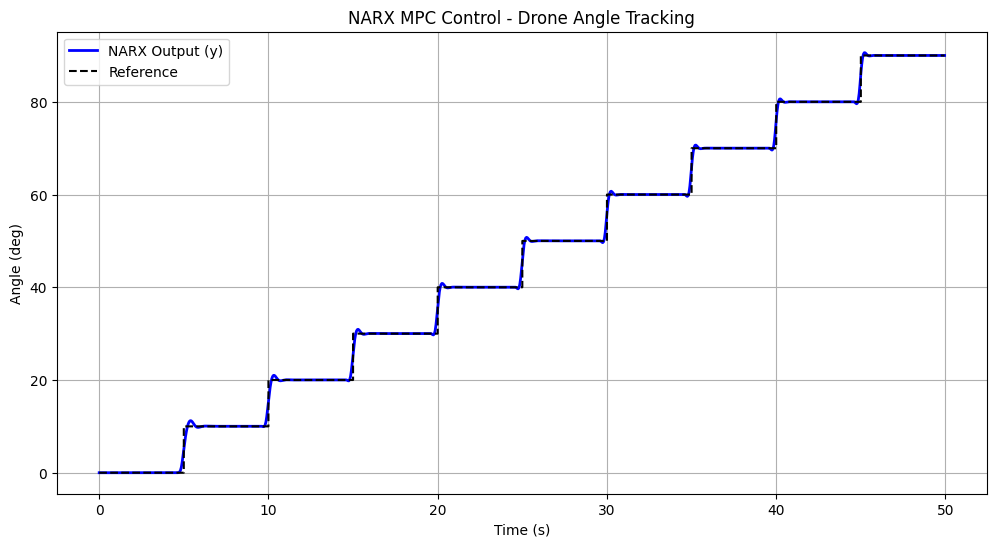

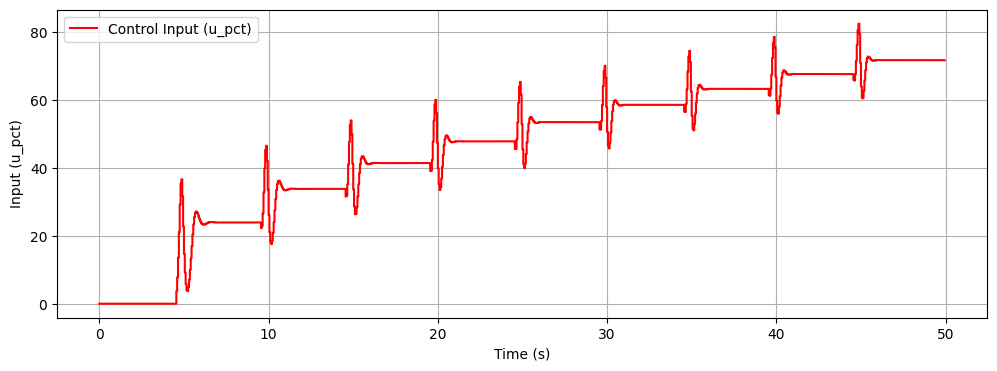

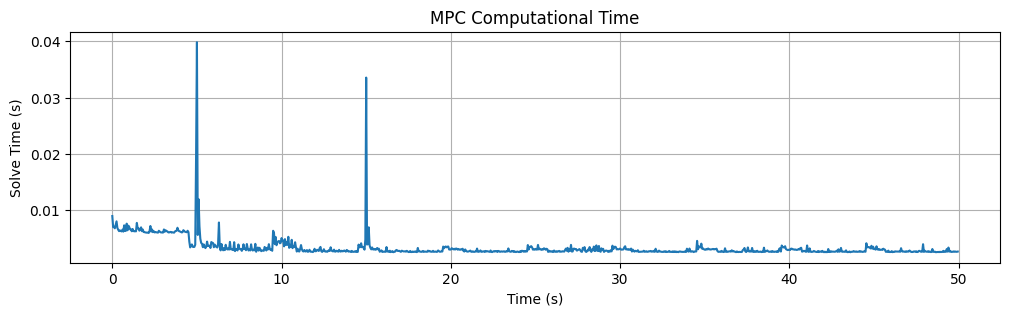

In [22]:
# 6. Plotting Results
plt.figure(figsize=(12, 6))
plt.plot(tvec_sim, ysim, 'b-', linewidth=2, label='NARX Output (y)')
plt.step(tvec_sim, x2ref[:len(tvec_sim)], where='post', color='k', linestyle='--', label='Reference')
plt.ylabel('Angle (deg)')
plt.xlabel('Time (s)')
plt.title('NARX MPC Control - Drone Angle Tracking')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.step(tvec_sim, usim, where='post', color='r', label='Control Input (u_pct)')
plt.ylabel('Input (u_pct)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(tvec_sim, dtvec)
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Solve Time (s)')
plt.title('MPC Computational Time')
plt.show()


## Dataset Generation
Using a rich combination of sine, step, and chirp signals.

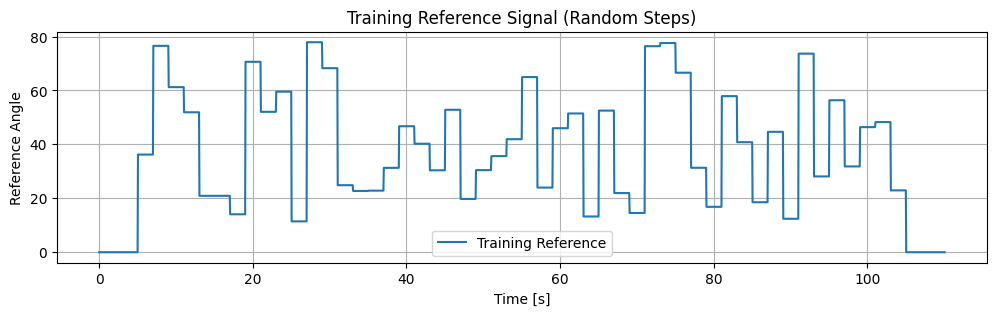

In [23]:
# 7. Reference Sequence Generation (Adjustable Random Steps)
np.random.seed(42)

# --- ADJUSTABLE PARAMETERS ---
n_steps = 50          # Number of random steps
step_duration = 2.0   # Duration of each step in seconds
amp_min = 10.0        # Minimum amplitude for the steps
amp_max = 80.0        # Maximum amplitude for the steps
zero_duration = 5.0   # Duration of zero-signal padding at start and end [s]
# -----------------------------

train_pieces = []
for i in range(n_steps):
    # Generate a random amplitude for this step
    S = np.random.uniform(amp_min, amp_max) 
    samples_step = int(round(step_duration / Ts))
    train_pieces.append(np.full(samples_step, S))

# Initial and final zero padding
n_zero_samples = int(round(zero_duration / Ts)) + 1 
zerovec = np.zeros(n_zero_samples)
x2ref_train = np.concatenate([zerovec, np.concatenate(train_pieces), zerovec])

steps_train = len(x2ref_train)
tvec_train = np.arange(0, steps_train * Ts, Ts)

# Plotting the generated steps
plt.figure(figsize=(12, 3))
plt.plot(tvec_train, x2ref_train, label='Training Reference')
plt.xlabel('Time [s]')
plt.ylabel('Reference Angle')
plt.title('Training Reference Signal (Random Steps)')
plt.legend()
plt.grid(True)
plt.show()


# # 7. Reference Sequence Generation (Rich Signal for Dataset)
# np.random.seed(42)

# N_pairs = 20
# train_pieces = []
# for i in range(N_pairs):
#     S = np.random.uniform(10.0, 80.0) 
#     step_duration1 = np.random.uniform(5.0, 10.0)
#     samples_step1 = int(round(step_duration1 / Ts))
#     train_pieces.append(np.full(samples_step1, S))
    
#     f = np.random.uniform(0.1, 0.5)
#     T_period = 1.0 / f
#     samples_sine = int(round((2 * T_period) / Ts))
#     t_sine = np.arange(0, samples_sine * Ts, Ts)
#     A = np.random.uniform(5.0, 10.0)
#     sine_wave = S + A * np.sin(2 * np.pi * f * t_sine)
#     train_pieces.append(sine_wave)
    
#     step_duration2 = np.random.uniform(5.0, 10.0)
#     samples_step2 = int(round(step_duration2 / Ts))
#     train_pieces.append(np.full(samples_step2, S))

# zero_seconds = 5.0
# n_zero_seconds = int(round(zero_seconds / Ts)) + 1 
# zerovec = np.zeros(n_zero_seconds)
# x2ref_train = np.concatenate([zerovec, np.concatenate(train_pieces), zerovec])

# steps_train = len(x2ref_train)
# tvec_train = np.arange(0, steps_train * Ts, Ts)

# plt.figure(figsize=(12, 3))
# plt.plot(tvec_train, x2ref_train, label='Training Reference')
# plt.xlabel('Time [s]')
# plt.ylabel('Reference Angle')
# plt.title('Training Reference Signal (Rich)')
# plt.legend()
# plt.grid(True)
# plt.show()


Simulating MPC over Rich Signal for Dataset...


MPC Dataset Collection:   0%|          | 0/2192 [00:00<?, ?it/s]

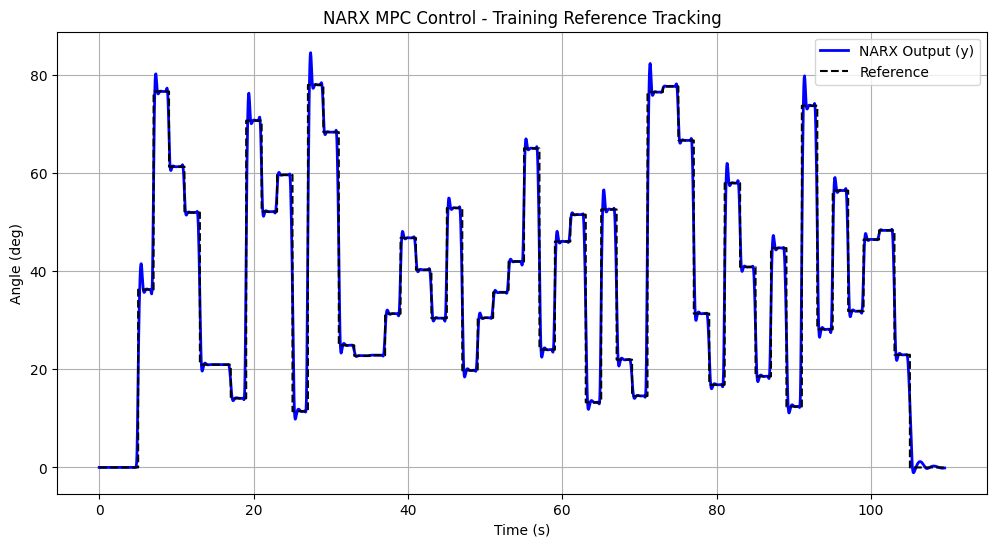

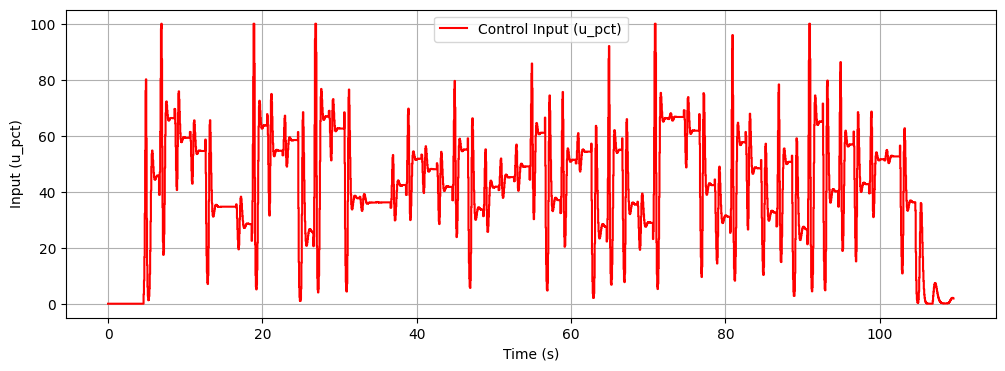

In [24]:
# 8. Simulation Loop (Rich Signal Dataset Collection)
import time
from tqdm.auto import tqdm

xsim_train = np.zeros((nx, 1))
ysim_train = []
usim_train = []
w0_val = np.zeros(w.shape[0])

print("Simulating MPC over Rich Signal for Dataset...")
sim_steps_train = steps_train - N
for k in tqdm(range(sim_steps_train), desc="MPC Dataset Collection"):
    ref_window = x2ref_train[k : k + N]
    pval = np.concatenate([xsim_train[:, -1], ref_window])
    
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx]
    
    sim_step = F(x0=xsim_train[:, -1], p=u_opt)
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim_train = np.c_[xsim_train, xk1]
    usim_train.append(u_opt)
    ysim_train.append(yk)
    w0_val = w_opt

# Collect Dataset for ANN
# P_data = np.array([np.concatenate([xsim_train[:, k], x2ref_train[k : k + N]]) for k in range(sim_steps_train)])
P_data = np.array([np.concatenate([[xsim_train[0, k]], x2ref_train[k : k + N]]) for k in range(sim_steps_train)])
U_data = np.array(usim_train).reshape(-1, 1)


# --- Plotting MPC Results ---
tvec_sim_train = tvec_train[:sim_steps_train]
# 1. Output (y) vs Reference
plt.figure(figsize=(12, 6))
plt.plot(tvec_sim_train, ysim_train, 'b-', linewidth=2, label='NARX Output (y)')
plt.step(tvec_sim_train, x2ref_train[:sim_steps_train], where='post', color='k', linestyle='--', label='Reference')
plt.ylabel('Angle (deg)')
plt.xlabel('Time (s)')
plt.title('NARX MPC Control - Training Reference Tracking')
plt.grid(True)
plt.legend()
plt.show()
# 2. Control Input (u)
plt.figure(figsize=(12, 4))
plt.step(tvec_sim_train, usim_train, where='post', color='r', label='Control Input (u_pct)')
plt.ylabel('Input (u_pct)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.legend()
plt.show()


Training ANN...
Epoch 10/100 - Train Loss: 85.3805 - Val Loss: 66.3871
Epoch 20/100 - Train Loss: 82.3341 - Val Loss: 59.2157
Epoch 30/100 - Train Loss: 71.7279 - Val Loss: 64.3363
Epoch 40/100 - Train Loss: 68.3035 - Val Loss: 76.3043
Epoch 50/100 - Train Loss: 67.2331 - Val Loss: 47.9762
Epoch 60/100 - Train Loss: 75.4135 - Val Loss: 90.2192
Epoch 70/100 - Train Loss: 61.9330 - Val Loss: 57.1360
Epoch 80/100 - Train Loss: 62.0459 - Val Loss: 46.1315
Epoch 90/100 - Train Loss: 61.5157 - Val Loss: 49.1301
Epoch 100/100 - Train Loss: 58.3771 - Val Loss: 40.1912


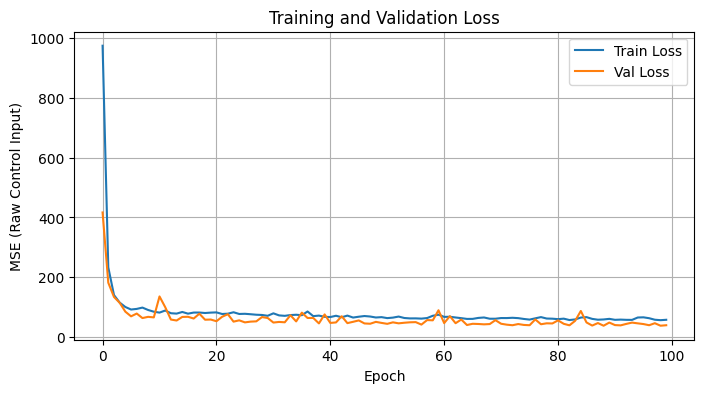

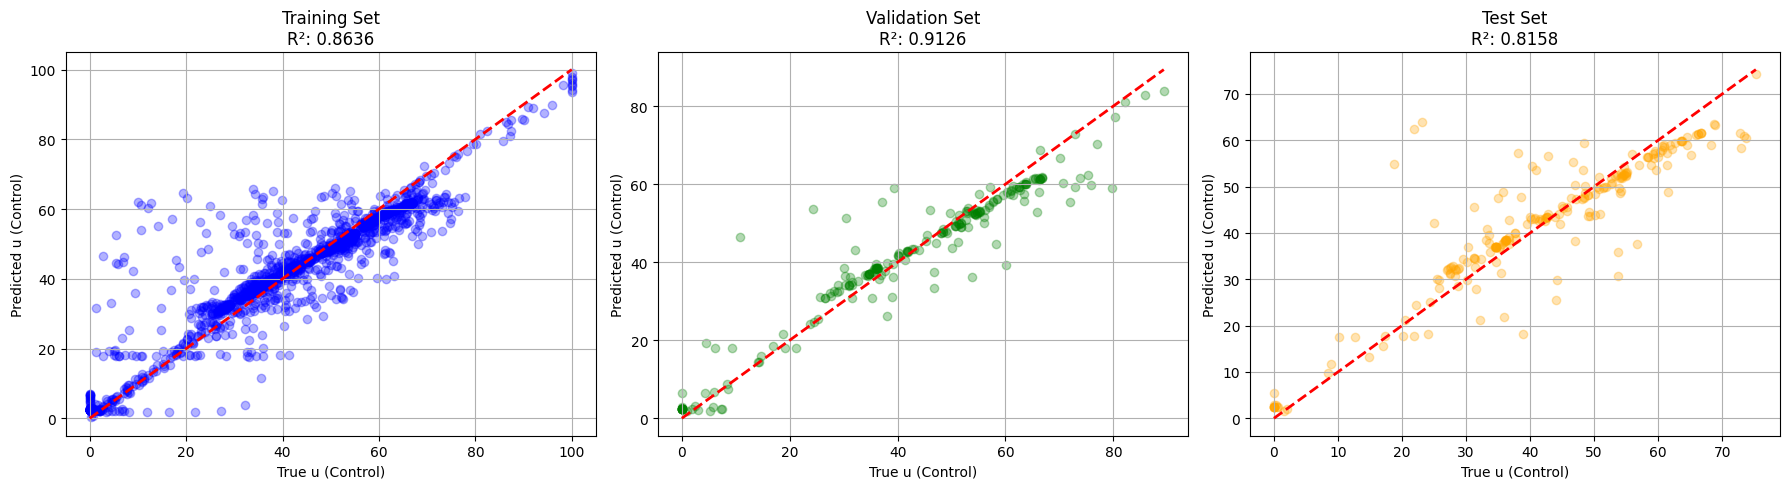

In [28]:
# 9. ANN Creation and Training
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Define the MLP (increased capacity for nx+N=35 inputs)
class MPCApproximator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MPCApproximator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

# Normalize inputs ONLY using StandardScaler to match robust template
scaler = StandardScaler()
P_scaled = scaler.fit_transform(P_data)

# Split data into train, validation, and test sets to monitor overfitting and evaluate generalization
X_train_val, X_test, y_train_val, y_test = train_test_split(P_scaled, U_data, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1111, random_state=42)

tensor_X_train = torch.tensor(X_train, dtype=torch.float32)
tensor_y_train = torch.tensor(y_train, dtype=torch.float32)
tensor_X_val = torch.tensor(X_val, dtype=torch.float32)
tensor_y_val = torch.tensor(y_val, dtype=torch.float32)
tensor_X_test = torch.tensor(X_test, dtype=torch.float32)
tensor_y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(tensor_X_train, tensor_y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# model = MPCApproximator(input_dim=nx + N, output_dim=1)
model = MPCApproximator(input_dim=1 + N, output_dim=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 100
train_loss_history = []
val_loss_history = []

print("Training ANN...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_loss_history.append(epoch_loss / len(train_loader))
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(tensor_X_val)
        val_loss = criterion(val_outputs, tensor_y_val).item()
    val_loss_history.append(val_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss_history[-1]:.4f} - Val Loss: {val_loss_history[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (Raw Control Input)")
plt.legend()
plt.grid()
plt.show()

# Plot y vs yhat on training, val, and test (side by side)
model.eval()
with torch.no_grad():
    y_train_pred = model(tensor_X_train).numpy()
    y_val_pred = model(tensor_X_val).numpy()
    y_test_pred = model(tensor_X_test).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training plot
axes[0].scatter(y_train, y_train_pred, alpha=0.3, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_title(f"Training Set\nR²: {r2_score(y_train, y_train_pred):.4f}")
axes[0].set_xlabel("True u (Control)")
axes[0].set_ylabel("Predicted u (Control)")
axes[0].grid(True)

# Validation plot
axes[1].scatter(y_val, y_val_pred, alpha=0.3, color='green')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_title(f"Validation Set\nR²: {r2_score(y_val, y_val_pred):.4f}")
axes[1].set_xlabel("True u (Control)")
axes[1].set_ylabel("Predicted u (Control)")
axes[1].grid(True)

# Test plot
axes[2].scatter(y_test, y_test_pred, alpha=0.3, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title(f"Test Set\nR²: {r2_score(y_test, y_test_pred):.4f}")
axes[2].set_xlabel("True u (Control)")
axes[2].set_ylabel("Predicted u (Control)")
axes[2].grid(True)

plt.tight_layout()
plt.show()


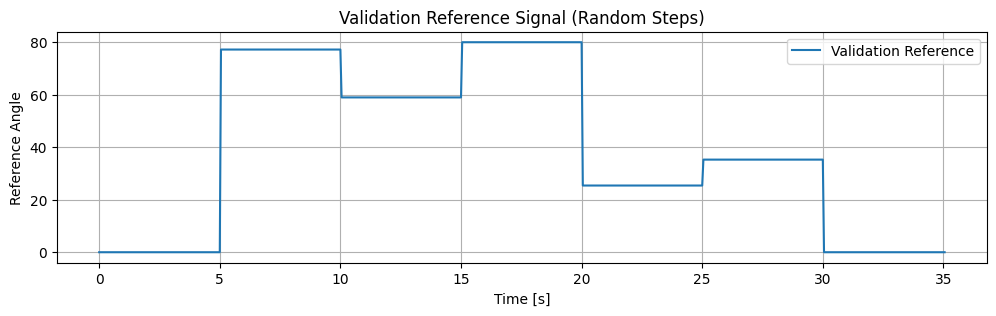

In [26]:
# 10. Validation Test Signal Generation
np.random.seed(24)  # Different seed than training to ensure a unique validation signal

# --- ADJUSTABLE PARAMETERS ---
n_steps_val = 5          # Number of validation random steps
step_duration_val = 5.0   # Duration of each step in seconds
amp_min_val = 10.0        # Minimum amplitude for the steps
amp_max_val = 80.0        # Maximum amplitude for the steps
zero_duration_val = 5.0   # Duration of zero-signal padding at start and end [s]
# -----------------------------

val_pieces = []
for i in range(n_steps_val):
    # Generate a random amplitude for this step
    S = np.random.uniform(amp_min_val, amp_max_val) 
    samples_step = int(round(step_duration_val / Ts))
    val_pieces.append(np.full(samples_step, S))

# Initial and final zero padding
n_zero_samples = int(round(zero_duration_val / Ts)) + 1 
zerovec = np.zeros(n_zero_samples)
x2ref_val = np.concatenate([zerovec, np.concatenate(val_pieces), zerovec])

steps_test = len(x2ref_val)
tvec_test = np.arange(0, steps_test * Ts, Ts)

plt.figure(figsize=(12, 3))
plt.plot(tvec_test, x2ref_val, label='Validation Reference')
plt.xlabel('Time [s]')
plt.ylabel('Reference Angle')
plt.title('Validation Reference Signal (Random Steps)')
plt.legend()
plt.grid(True)
plt.show()


# # 10. Validation Test Signal Generation
# step_duration = 5.0
# samples_per_step = int(round(step_duration / Ts))

# steps_up = np.arange(0, 75, 15) # 0, 15, 30, 45, 60
# steps_down = np.array([45])
# f_sine = 0.5
# T_period = 1.0 / f_sine
# sine_duration = 2 * T_period
# t_sine = np.arange(0, sine_duration, Ts)

# sine_wave = 45 + 15 * np.sin(2 * np.pi * f_sine * t_sine)
# steps_end = np.array([45, 30, 15, 0])

# ref_pieces = []
# for val in steps_up:
#     ref_pieces.append(np.full(samples_per_step, val))
# for val in steps_down:
#     ref_pieces.append(np.full(samples_per_step, val))
# ref_pieces.append(sine_wave)
# for val in steps_end:
#     ref_pieces.append(np.full(samples_per_step, val))

# zero_seconds = 5.0
# n_zero_seconds = int(round(zero_seconds / Ts)) + 1 
# zerovec = np.zeros(n_zero_seconds)
# x2ref_val = np.concatenate([zerovec, np.concatenate(ref_pieces), zerovec])

# steps_test = len(x2ref_val)
# tvec_test = np.arange(0, steps_test * Ts, Ts)

# plt.figure(figsize=(12, 3))
# plt.plot(tvec_test, x2ref_val, label='Validation Reference')
# plt.xlabel('Time [s]')
# plt.ylabel('Reference Angle')
# plt.title('Validation Reference Signal')
# plt.legend()
# plt.grid(True)
# plt.show()


Simulating Optimal MPC on Test Signal...
Simulating ANN on Test Signal...
MPC Simulation Time: 2.74 s
ANN Simulation Time: 0.06 s
Speedup Factor: 44.23x


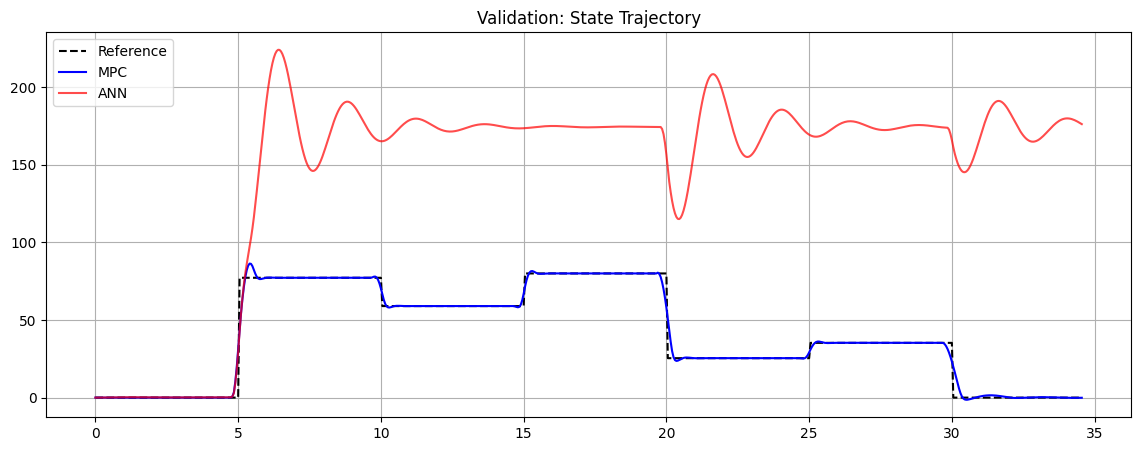

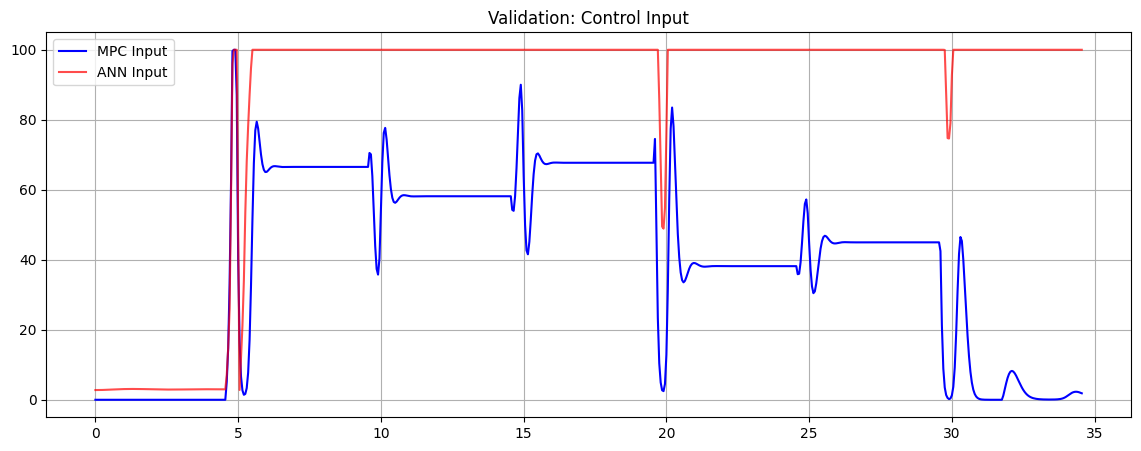

In [27]:
# 11. Validation Simulation (MPC vs ANN)
# Simulate MPC for Validation
xsim_val_mpc = np.zeros((nx, 1))
ysim_val_mpc = []
usim_val_mpc = []
w0_val = np.zeros(w.shape[0])

sim_steps_test = steps_test - N

start_time = time.time()
print("Simulating Optimal MPC on Test Signal...")
for k in range(sim_steps_test):
    ref_window = x2ref_val[k : k + N]
    pval = np.concatenate([xsim_val_mpc[:, -1], ref_window])
    
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx]
    
    sim_step = F(x0=xsim_val_mpc[:, -1], p=u_opt)
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim_val_mpc = np.c_[xsim_val_mpc, xk1]
    usim_val_mpc.append(u_opt)
    ysim_val_mpc.append(yk)
    w0_val = w_opt
mpc_time = time.time() - start_time

# Simulate ANN
xsim_val_ann = np.zeros((nx, 1))
ysim_val_ann = []
usim_val_ann = []

start_time = time.time()
print("Simulating ANN on Test Signal...")
model.eval()
with torch.no_grad():
    for k in range(sim_steps_test):
        ref_window = x2ref_val[k : k + N]
        # pval = np.concatenate([xsim_val_ann[:, -1], ref_window])
        pval = np.concatenate([[xsim_val_ann[0, -1]], ref_window])
        
        # Normalize input exactly as in training
        pval_scaled = scaler.transform(pval.reshape(1, -1))
        p_tensor = torch.tensor(pval_scaled, dtype=torch.float32)
        
        # Predict (Directly outputs raw control value since we didn't scale Y)
        u_opt = model(p_tensor).item()
        
        # Bound the ANN output to strictly respect limits
        u_opt = np.clip(u_opt, data['u_min'][0], data['u_max'][0])
        
        sim_step = F(x0=xsim_val_ann[:, -1], p=u_opt)
        xk1 = sim_step['xf'].full().flatten()
        yk = sim_step['yk'].full().item()
        
        xsim_val_ann = np.c_[xsim_val_ann, xk1]
        usim_val_ann.append(u_opt)
        ysim_val_ann.append(yk)
ann_time = time.time() - start_time

print(f"MPC Simulation Time: {mpc_time:.2f} s")
print(f"ANN Simulation Time: {ann_time:.2f} s")
print(f"Speedup Factor: {mpc_time/ann_time:.2f}x")

tvec_plot = np.arange(0, sim_steps_test * Ts, Ts)

plt.figure(figsize=(14, 5))
plt.plot(tvec_plot, x2ref_val[:sim_steps_test], 'k--', label='Reference')
plt.plot(tvec_plot, ysim_val_mpc, 'b-', label='MPC')
plt.plot(tvec_plot, ysim_val_ann, 'r-', alpha=0.7, label='ANN')
plt.title('Validation: State Trajectory')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(tvec_plot, usim_val_mpc, 'b-', label='MPC Input')
plt.plot(tvec_plot, usim_val_ann, 'r-', alpha=0.7, label='ANN Input')
plt.title('Validation: Control Input')
plt.legend()
plt.grid()
plt.show()
